# Linear Regression — Height vs Weight
Goal: Predict weight from height using simple linear regression.

Dataset: height_weight.csv  
Library: scikit-learn, pandas, matplotlib

## 1. Import Libraries

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
%matplotlib inline
print('Libraries imported successfully!')

Libraries imported successfully!



## 2. Load the Dataset

In [71]:
df=pd.read_csv('height_weight_lr.csv')

print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Dataset Shape: 700 rows × 2 columns
Columns: ['Weight', 'Height']


## 3. Exploratory Data Analysis

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  700 non-null    int64
 1   Height  700 non-null    int64
dtypes: int64(2)
memory usage: 11.1 KB


In [73]:
df.describe().round(2)

,Weight,Height
count,700.00,700.00
mean,75.00,153.09
std,17.36,16.84
min,45.00,117.00
25%,60.00,138.75
50%,75.00,154.00
75%,90.00,167.00
max,105.00,189.00


In [74]:
#checking for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')

Missing values per column:
Weight    0
Height    0
dtype: int64

Total missing: 0


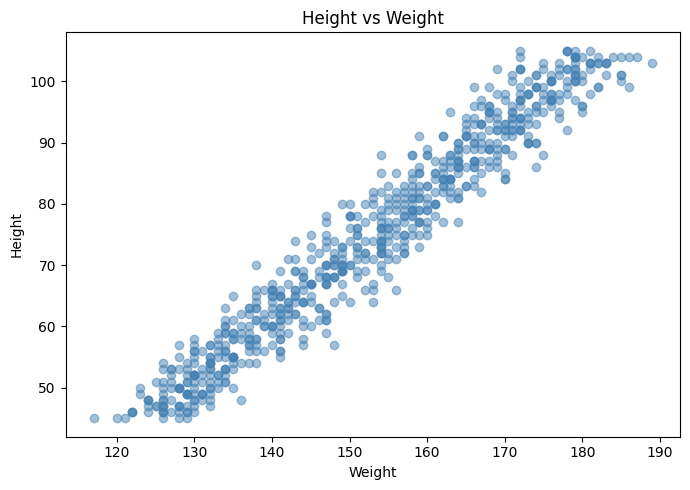

In [75]:
# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(df['Height'], df['Weight'], alpha=0.5, color='steelblue')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Height vs Weight')
plt.tight_layout()
plt.show()

In [76]:
corr = df[['Weight', 'Height']].corr()
print('Correlation Matrix:')
print(corr.round(4))
print(f'\nPearson Correlation between Weight and Height: {corr.loc["Weight", "Height"]:.4f}')

Correlation Matrix:
        Weight  Height
Weight  1.0000  0.9724
Height  0.9724  1.0000

Pearson Correlation between Weight and Height: 0.9724


## 4. Data Preprocessing

We split the data into features (x) and target (y), then into train and test sets.

In [77]:
df.head(2)

,Weight,Height
0,45,126
1,45,121


In [78]:
x = df[['Weight']] #2D array for sklearn
y = df['Height'] #This can be 1D for sklearn
print(np.array(x).shape)
print(np.array(y).shape)

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print(f"Total samples: {len(df)}")
print(f"Training set: {len(x_train)} samples ({len(x_train)/len(df)*100:.0f}%)")
print(f"Testing set: {len(x_test)} samples ({len(x_test)/len(df)*100:.0f}%)")

(700, 1)
(700,)
Total samples: 700
Training set: 560 samples (80%)
Testing set: 140 samples (20%)


## 5. Standardization

In [79]:
scalar = StandardScaler()
x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)

## 6. Model

In [80]:
model = LinearRegression()
model.fit(x_train_scaled,y_train)

print("Model Trained Successfully")
print(f'\nRegression Equation:')
print(f'Height = ({model.coef_[0]:.4f}) × Weight + ({model.intercept_:.4f})')
print(f'\nInterpretation:')
print(f'For every 1 unit increase in Weight, Height increases by {model.coef_[0]:.4f} units.')

Model Trained Successfully

Regression Equation:
Height = (16.2250) × Weight + (153.5232)

Interpretation:
For every 1 unit increase in Weight, Height increases by 16.2250 units.


## 7. Model Evaluation

In [81]:
y_pred = model.predict(x_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('─' * 35)
print(f'  MSE   : {mse:.4f}')
print(f'  MAE   : {mae:.4f}')
print(f'  RMSE  : {rmse:.4f}')
print(f'  R²    : {r2:.4f}')
print('─' * 35)

───────────────────────────────────
  MSE   : 15.8251
  MAE   : 3.1749
  RMSE  : 3.9781
  R²    : 0.9469
───────────────────────────────────


## 8. Visualization

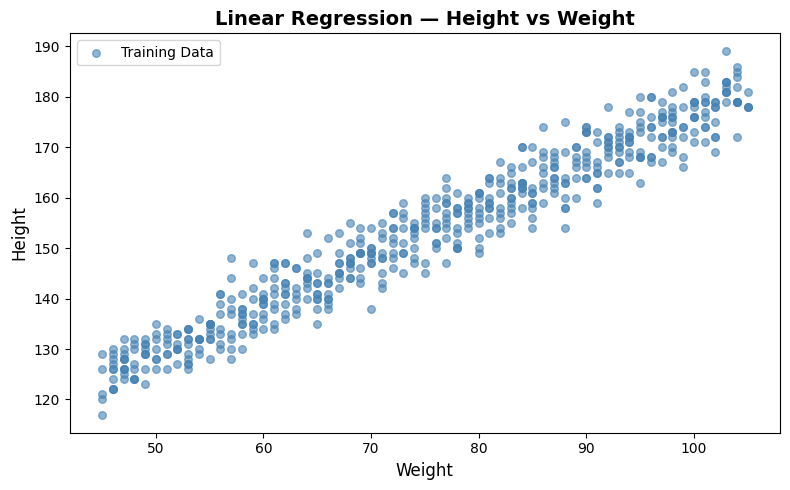

In [82]:
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color='steelblue', alpha=0.6, label='Training Data', s=30)
plt.xlabel('Weight', fontsize=12)
plt.ylabel('Height', fontsize=12)
plt.title('Linear Regression — Height vs Weight', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
print("model.coef_:", model.coef_[0].round(4))
print("model.intercept_:", model.intercept_.round(4))

model.coef_: 16.225
model.intercept_: 153.5232


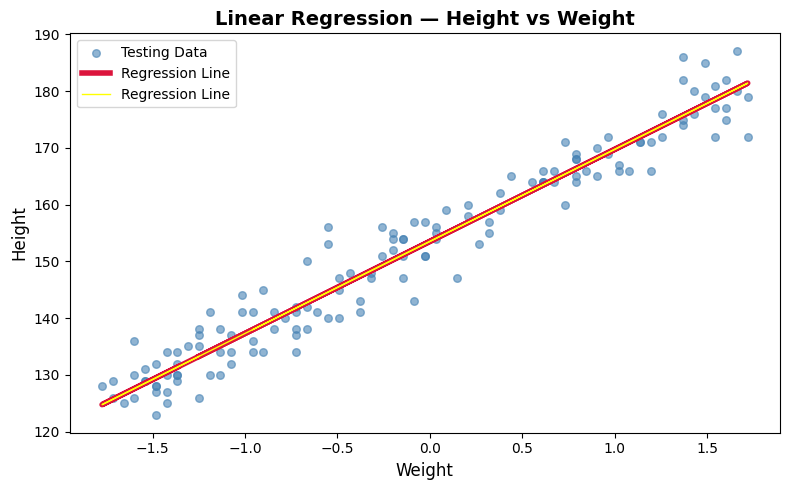

In [84]:
plt.figure(figsize=(8, 5))
plt.scatter(x_test_scaled, y_test, color='steelblue', alpha=0.6, label='Testing Data', s=30)
plt.plot(x_train_scaled,
        model.predict(x_train_scaled),
        color='crimson', linewidth=4, label='Regression Line')
plt.plot(x_test_scaled,
        model.predict(x_test_scaled),
        color='yellow', linewidth=1, label='Regression Line')
plt.xlabel('Weight', fontsize=12)
plt.ylabel('Height', fontsize=12)
plt.title('Linear Regression — Height vs Weight', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 9. New Prediction

In [85]:
sample_weights = [45, 58, 61, 72, 83, 87]

sample_weights_scaled = scalar.transform(np.array(sample_weights).reshape(-1, 1))
predictions = model.predict(sample_weights_scaled)

print(f'{'Weight':>10}  {'Predicted Height':>18}')
print('─' * 32)
for w, h in zip(sample_weights, predictions):
    print(f'{w:>10}  {h:>18.2f}')

    Weight    Predicted Height
────────────────────────────────
        45              124.75
        58              137.03
        61              139.86
        72              150.25
        83              160.64
        87              164.42


c:\Users\master\OneDrive\Desktop\height_weight_lr\height-weight-linear-regression\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [86]:
df.head(2)

,Weight,Height
0,45,126
1,45,121


### Assumptions


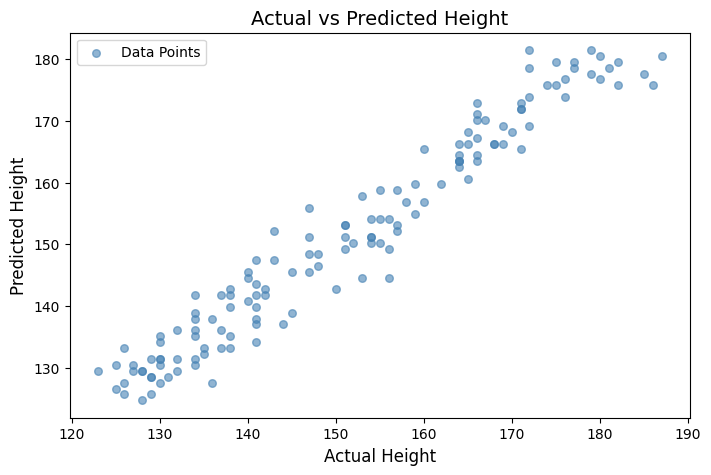

In [87]:
# plot a scatter plot between test y and predicted y
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.6, label='Data Points', s=30)
plt.xlabel('Actual Height', fontsize=12)
plt.ylabel('Predicted Height', fontsize=12)
plt.title('Actual vs Predicted Height', fontsize=14)
plt.legend()
plt.show()


If this plot is linear, in this case it, the model has done a good job

In [88]:
# residuals
residuals = y_test - y_pred
residuals

158   -1.972961
500    5.634034
396    3.135311
155    6.971626
321   -0.197170
         ...   
24    -1.637924
218   -0.695893
431    2.301552
281   -6.418825
110    1.749971
Name: Height, Length: 140, dtype: float64

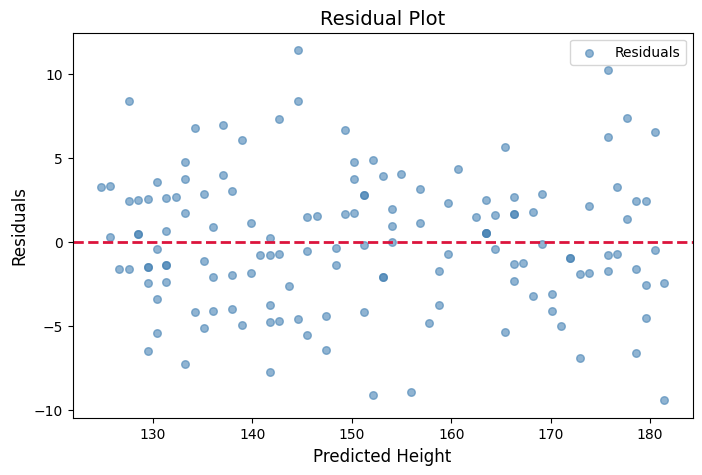

In [89]:
#plot residuals
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color='steelblue', alpha=0.6, label='Residuals', s=30)
plt.axhline(y=0, color='crimson', linestyle='--', linewidth=2)
plt.xlabel('Predicted Height', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot', fontsize=14)
plt.legend()
plt.show()

Plot between predicted y and residual shall be uniformly distributed for it to be a good model

<Axes: xlabel='Height', ylabel='Count'>

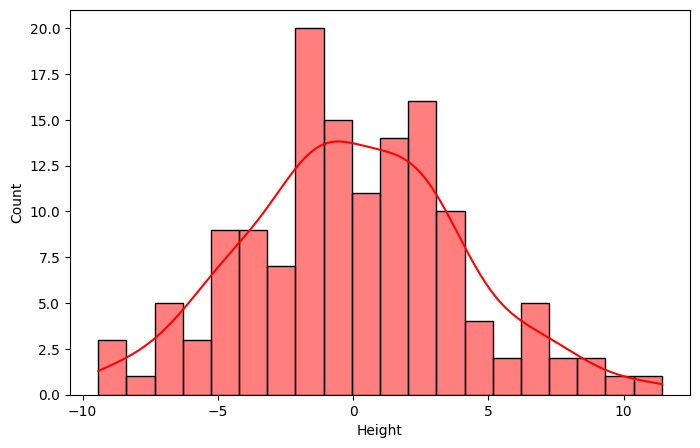

In [90]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, color='red', bins=20, kde=True)


The plot of residuals shall follow a normal distributions for it be a good model

## 10. Conclusion

- The data shows a strong positive correlation between Height and Weight.
- Our Linear Regression model captured this relationship well, achieving an R² of ~0.94 on the test set.
- The regression equation is: Height = (16.2250) × Weight + (153.5232)

### What I Learned
- How to do proper EDA before preparing a model. 
- How to interpret model coefficients.
- How R², MSE, and RMSE each tell a different part of the story.

## 11. Save model as a pickle file

In [91]:
pickle.dump(model, open('height_weight_lr_model.pkl', 'wb'))
print("Model saved as 'height_weight_lr_model.pkl'")

Model saved as 'height_weight_lr_model.pkl'


In [92]:
model_loaded = pickle.load(open('height_weight_lr_model.pkl', 'rb'))
print("Model loaded successfully!")

Model loaded successfully!


In [106]:
model_pred=model_loaded.predict(x_test_scaled[:5])
for i, pred in enumerate(model_pred):
    print(f'Predicted Height for Weight {x_test_scaled[i][0]:.4f} : {pred:.2f}')

Predicted Height for Weight -0.9584 : 137.97
Predicted Height for Weight 0.7299 : 165.37
Predicted Height for Weight 0.2059 : 156.86
Predicted Height for Weight -1.0166 : 137.03
Predicted Height for Weight -0.1434 : 151.20
